# EMG Gesture Classification — NinaPro DB1 (Exercise A)

**Goal:** classify 12 finger/thumb gestures (flexion/extension of index, middle, ring,
little finger; thumb adduction/abduction/flexion/extension) from 10-channel surface EMG,
as a first step toward EMG-driven prosthetic hand control.

**Dataset:** [NinaPro DB1](http://ninapro.hevs.ch), Subject 1, Exercise A
(Atzori et al., *Building the NinaPro Database*, BioRob 2012). Signals are pre-processed
by the database authors (rectified, low-pass filtered, resampled to 100 Hz).

**Pipeline overview:**
1. Load raw `.mat` data and explore the signal
2. Detect gesture repetition boundaries from the `restimulus` label
3. **Baseline v0** — one feature vector per repetition (naive, and why it fails)
4. **Final approach** — sliding-window feature extraction (200 ms windows, 50% overlap)
5. Classical ML: Random Forest, KNN
6. Neural network: MLP, with and without EarlyStopping
7. Results summary, limitations, and next steps

*Note on structure: earlier iterations of this notebook also tried a richer
single-vector-per-repetition feature set and a fixed 3-way sub-window split before
arriving at the sliding-window approach below. Those intermediate attempts are
summarized in Section 3 rather than kept as separate code, since the final sliding-window
method supersedes both and produces far more training data.*


## 1. Setup

In [9]:
# scipy.io: for loading .mat files (MATLAB format)
import scipy.io as sio

# numpy: numerical operations (arrays, math)
import numpy as np

# matplotlib.pyplot: plotting EMG signals and training curves
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load and Inspect the Raw Data

In [10]:
file_path = 'ninaprodb/s1/S1_A1_E1.mat'
data = sio.loadmat(file_path)

print("Keys in the .mat file:", data.keys())


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'emg', 'stimulus', 'glove', 'subject', 'exercise', 'repetition', 'restimulus', 'rerepetition'])


Each `.mat` file stores several parallel signals, all synchronized sample-by-sample:

| Field | Meaning |
|---|---|
| `emg` | (n_samples, 10) — the 10-electrode sEMG signal, pre-processed to 100 Hz |
| `stimulus` | Raw movement label as originally presented to the subject |
| `restimulus` | **Corrected** movement label, realigned to when the subject actually moved (used throughout this project — see note below) |
| `repetition` | Which of the 10 repetitions of each gesture this sample belongs to |
| `subject`, `exercise` | Metadata identifying the recording |

**Why `restimulus` and not `stimulus`:** the raw `stimulus` signal marks *when the movie
cue appeared on screen*, but subjects react with a short delay. `restimulus` is
realigned to the subject's actual EMG onset, giving cleaner class boundaries. This
project uses `restimulus` throughout after an earlier version mistakenly used `stimulus`.

In [11]:
emg = data['emg']
restimulus = data['restimulus'].flatten()
stimulus = data['stimulus'].flatten()
repetition = data['repetition'].flatten()
fs = 100  # Hz — NinaPro DB1 is pre-processed/resampled to 100 Hz by the database authors

print("EMG shape:", emg.shape)                # (n_samples, 10 electrodes)
print("Restimulus shape:", restimulus.shape)
print("Sampling frequency:", fs, "Hz")
print("Unique gestures:", np.unique(restimulus))   # 0 = rest, 1-12 = gestures
print("Unique repetitions:", np.unique(repetition))


EMG shape: (101014, 10)
Restimulus shape: (101014,)
Sampling frequency: 100 Hz
Unique gestures: [ 0  1  2  3  4  5  6  7  8  9 10 11 12]
Unique repetitions: [ 0  1  2  3  4  5  6  7  8  9 10]


## 3. Signal Exploration (EDA)

A quick sanity-check plot of two different gestures confirms the raw EMG looks reasonable and visually distinct before building any pipeline on top of it.

In [12]:
def plot_gesture_raw(gesture_id, gesture_name, n_samples=200):
    idx = np.where(restimulus == gesture_id)[0]
    start, end = idx[0], idx[0] + n_samples
    plt.figure(figsize=(12, 5))
    for i in range(10):
        plt.plot(emg[start:end, i], label=f'Electrode {i+1}')
    plt.xlabel('Samples (at 100 Hz)')
    plt.ylabel('EMG Amplitude')
    plt.title(f'Preprocessed EMG — Gesture {gesture_id} ({gesture_name})')
    plt.legend(fontsize=8, ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

plot_gesture_raw(1, "Index Flexion")
plot_gesture_raw(11, "Thumb Flexion")


<Figure size 1200x500 with 1 Axes>

<Figure size 1200x500 with 1 Axes>

**Finding repetition boundaries.** `restimulus` is a per-sample label; to build one
example per repetition (or per window) we need the *indices* where the label changes.
This is done by looking for jumps in `restimulus`.

In [13]:
gesture_starts = np.where(np.diff(restimulus) != 0)[0] + 1  # +1: diff() shifts index left
gesture_starts = np.insert(gesture_starts, 0, 0)              # include sample 0

print("Number of label changes detected:", len(gesture_starts))
print("First 10 start indices:", gesture_starts[:10])
print("Gesture label at those starts:", restimulus[gesture_starts[:10]])


Number of label changes detected: 241
First 10 start indices: [   0  440  745 1275 1629 2153 2499 3020 3391 3743]
Gesture label at those starts: [0 1 0 1 0 1 0 1 0 1]


**Sanity-checking the sampling rate.** The protocol calls for ~5 s of movement and
3 s of rest per repetition. An early version of this notebook assumed `fs = 2000 Hz`
(a common raw NinaPro rate) and got timing that didn't match the protocol at all —
that mismatch is what revealed this particular `.mat` file is already resampled to
100 Hz, matching the paper's stated preprocessing.

In [14]:
time_between_starts = np.diff(gesture_starts) / fs
print("Time between first 20 label changes (seconds), at fs=100Hz:")
print(np.round(time_between_starts[:20], 2))
print(f"\nMean: {time_between_starts.mean():.2f}s | Min: {time_between_starts.min():.2f}s | Max: {time_between_starts.max():.2f}s")


Time between first 20 label changes (seconds), at fs=100Hz:
[4.4  3.05 5.3  3.54 5.24 3.46 5.21 3.71 3.52 4.38 4.38 3.72 4.44 4.3
 4.74 4.12 3.24 4.35 4.54 3.52]

Mean: 4.19s | Min: 1.84s | Max: 8.82s


**Repetitions and durations per gesture** — confirms each of the 12 gestures has 10 repetitions, as expected from the NinaPro protocol.

In [15]:
def get_repetition_windows(gesture_id):
    """Return (start, end) sample indices for each repetition of a gesture."""
    starts = gesture_starts[restimulus[gesture_starts] == gesture_id]
    windows = []
    for start in starts:
        next_idx = np.searchsorted(gesture_starts, start, side='right')
        end = gesture_starts[next_idx] if next_idx < len(gesture_starts) else len(restimulus)
        windows.append((start, end))
    return windows

for g in range(1, 13):
    windows = get_repetition_windows(g)
    durations = np.array([e - s for s, e in windows])
    print(f"Gesture {g:2d}: {len(windows)} reps, avg duration = {durations.mean():.1f} samples "
          f"({durations.mean()/fs:.2f}s)")


Gesture  1: 10 reps, avg duration = 381.5 samples (3.81s)
Gesture  2: 10 reps, avg duration = 261.8 samples (2.62s)
Gesture  3: 10 reps, avg duration = 414.2 samples (4.14s)
Gesture  4: 10 reps, avg duration = 298.2 samples (2.98s)
Gesture  5: 10 reps, avg duration = 395.2 samples (3.95s)
Gesture  6: 10 reps, avg duration = 305.8 samples (3.06s)
Gesture  7: 10 reps, avg duration = 261.5 samples (2.62s)
Gesture  8: 10 reps, avg duration = 299.8 samples (3.00s)
Gesture  9: 10 reps, avg duration = 260.8 samples (2.61s)
Gesture 10: 10 reps, avg duration = 318.7 samples (3.19s)
Gesture 11: 10 reps, avg duration = 249.1 samples (2.49s)
Gesture 12: 10 reps, avg duration = 323.4 samples (3.23s)


**Comparing gestures visually.** Averaging each repetition's EMG (trimmed to the shortest repetition length) and overlaying gestures on one electrode gives a first qualitative sense of separability.

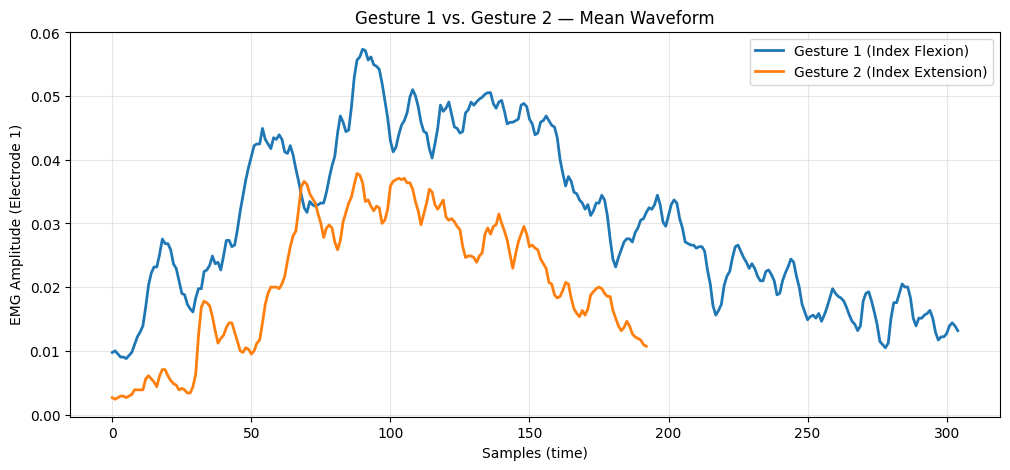

In [16]:
def mean_waveform(gesture_id, electrode=None):
    windows = get_repetition_windows(gesture_id)
    segments = [emg[s:e, :] for s, e in windows]
    min_len = min(seg.shape[0] for seg in segments)
    segments = [seg[:min_len, :] for seg in segments]
    mean_wave = np.mean(segments, axis=0)  # (min_len, 10)
    return mean_wave if electrode is None else mean_wave[:, electrode]

plt.figure(figsize=(12, 5))
plt.plot(mean_waveform(1, electrode=0), label="Gesture 1 (Index Flexion)", linewidth=2)
plt.plot(mean_waveform(2, electrode=0), label="Gesture 2 (Index Extension)", linewidth=2)
plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude (Electrode 1)")
plt.title("Gesture 1 vs. Gesture 2 — Mean Waveform")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


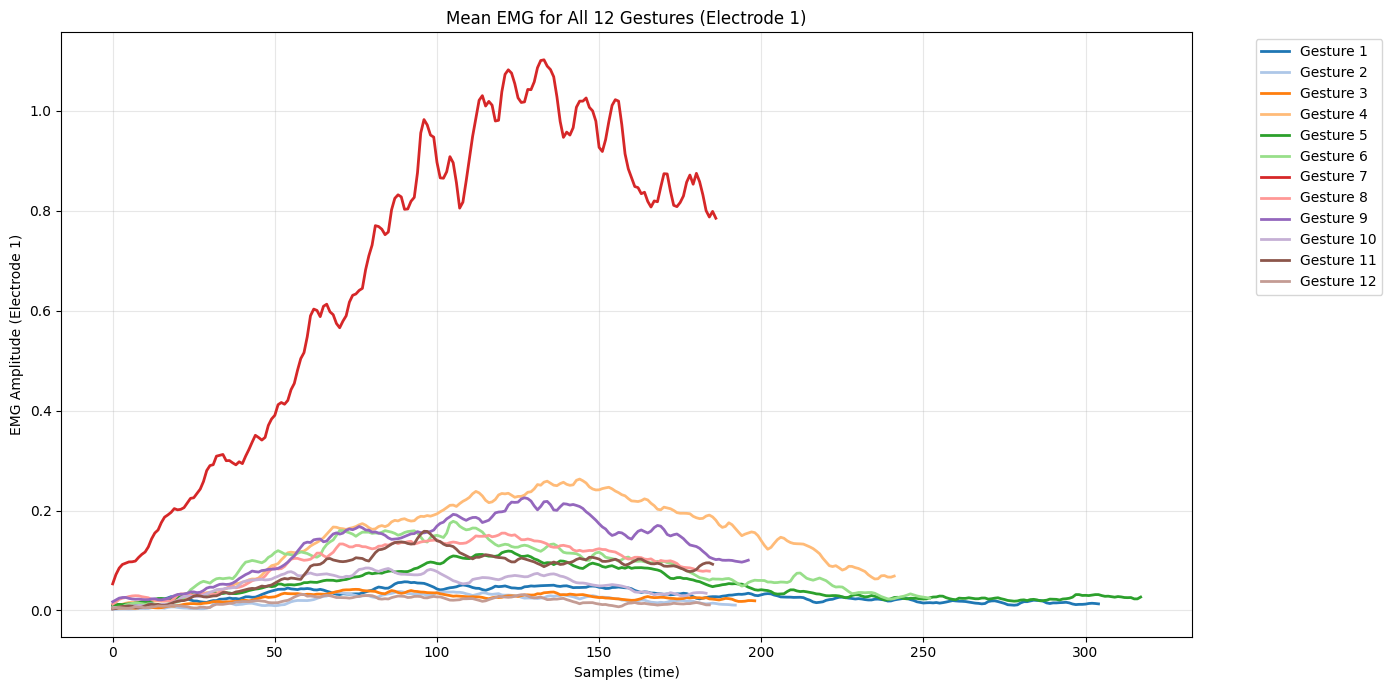

In [17]:
colors = plt.cm.tab20.colors
plt.figure(figsize=(14, 7))
for g in range(1, 13):
    plt.plot(mean_waveform(g, electrode=0), label=f"Gesture {g}", color=colors[g-1], linewidth=2)
plt.xlabel("Samples (time)")
plt.ylabel("EMG Amplitude (Electrode 1)")
plt.title("Mean EMG for All 12 Gestures (Electrode 1)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. Baseline v0 — Naive One-Vector-Per-Repetition

**First attempt:** collapse each entire repetition down to a single feature vector
(mean EMG per electrode) and train directly on that. This is the simplest possible
approach and a useful baseline, but it has a fundamental data-volume problem:
12 gestures x 10 repetitions = only **120 samples total**. An 80/20 split leaves
just ~24 test samples, so per-class accuracy can only take a handful of discrete
values (0%, 50%, 100% for a 2-sample class) — nowhere near enough to trust as a
reliable metric.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

X_v0, y_v0 = [], []
for g in range(1, 13):
    for start, end in get_repetition_windows(g):
        X_v0.append(np.mean(emg[start:end, :], axis=0))  # mean per electrode -> 10 features
        y_v0.append(g)

X_v0, y_v0 = np.array(X_v0), np.array(y_v0)
print("X shape:", X_v0.shape, "  (12 gestures x 10 reps, 10 features)")

X_train_v0, X_test_v0, y_train_v0, y_test_v0 = train_test_split(
    X_v0, y_v0, test_size=0.2, random_state=42, stratify=y_v0
)
clf_v0 = RandomForestClassifier(n_estimators=100, random_state=42)
clf_v0.fit(X_train_v0, y_train_v0)
y_pred_v0 = clf_v0.predict(X_test_v0)

print(f"\nTest set size: {len(y_test_v0)} samples for 12 classes")
print(classification_report(y_test_v0, y_pred_v0, zero_division=0))


X shape: (120, 10)   (12 gestures x 10 reps, 10 features)

Test set size: 24 samples for 12 classes
              precision    recall  f1-score   support

           1       1.00      0.50      0.67         2
           2       1.00      1.00      1.00         2
           3       0.67      1.00      0.80         2
           4       0.50      1.00      0.67         2
           5       1.00      1.00      1.00         2
           6       0.50      0.50      0.50         2
           7       1.00      0.50      0.67         2
           8       1.00      0.50      0.67         2
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         2
          12       1.00      1.00      1.00         2

    accuracy                           0.83        24
   macro avg       0.89      0.83      0.83        24
weighted avg       0.89      0.83      0.83        24



**Diagnosis:** the classification report above is noisy and unreliable purely due to
sample size — not a modeling problem. Two things were tried next before landing on the
real fix:

- **Richer features per repetition** (mean, std, min, max, RMS per electrode -> 50
  features instead of 10). This improved the *feature quality* per example but didn't
  address the core issue: still only 120 examples total.
- **Splitting each repetition into 3 fixed sub-windows** (start/middle/end thirds),
  tripling the dataset to 360 examples. Better, but still coarse and arbitrary.

**The actual fix:** slide a fixed-size window across each repetition with overlap,
generating many more (and more consistent) training examples per repetition. That's
the approach used from here on.


## 5. Final Feature Extraction — Sliding Window

Each repetition is scanned with a 200 ms window (20 samples at 100 Hz) and 50% overlap
(10-sample step). For every window, 5 statistics (mean, std, min, max, RMS) are computed
per electrode, giving 10 x 5 = **50 features per window**. Each window also records which
repetition it came from — needed for a leak-free train/test split (Section 6).

In [19]:
window_size = 20   # 200ms at 100Hz
step_size = 10      # 100ms step -> 50% overlap

X, y, rep = [], [], []

for g in range(1, 13):
    for start, end in get_repetition_windows(g):
        rep_number = repetition[start]
        window_start = start
        while window_start + window_size <= end:
            window = emg[window_start: window_start + window_size, :]  # (20, 10)
            features = []
            for electrode in range(10):
                signal = window[:, electrode]
                features.extend([
                    np.mean(signal), np.std(signal), np.min(signal),
                    np.max(signal), np.sqrt(np.mean(signal ** 2)),
                ])
            X.append(features)
            y.append(g)
            rep.append(rep_number)
            window_start += step_size

X, y, rep = np.array(X), np.array(y), np.array(rep)

print("X shape:", X.shape, " (windows, features)")
print("Windows per gesture:")
for g in np.unique(y):
    print(f"  Gesture {g:2d}: {np.sum(y == g)} windows")
print("Repetitions present:", np.unique(rep))


X shape: (3594, 50)  (windows, features)
Windows per gesture:
  Gesture  1: 368 windows
  Gesture  2: 247 windows
  Gesture  3: 401 windows
  Gesture  4: 283 windows
  Gesture  5: 380 windows
  Gesture  6: 291 windows
  Gesture  7: 246 windows
  Gesture  8: 285 windows
  Gesture  9: 247 windows
  Gesture 10: 303 windows
  Gesture 11: 235 windows
  Gesture 12: 308 windows
Repetitions present: [ 1  2  3  4  5  6  7  8  9 10]


## 6. Train/Test Split, Scaling, and Classical ML

**Repetition-based split (not random):** EMG samples within the same repetition are
temporally correlated (adjacent windows overlap by 50% and share muscle-activation
dynamics). A random split would leak information between train and test — the model
could partly "recognize" a repetition it has already partially seen rather than
generalizing to unseen movement instances. Splitting by whole repetitions (some
repetitions entirely held out) avoids this leakage and gives an honest accuracy estimate.


Train windows: 2144
Test windows: 1450

=== Random Forest ===
              precision    recall  f1-score   support

           1       0.80      0.85      0.82       152
           2       0.94      0.74      0.83       119
           3       0.66      0.76      0.71       135
           4       0.84      0.85      0.84       112
           5       0.92      0.93      0.92       157
           6       0.61      0.59      0.60       113
           7       0.91      0.89      0.90        97
           8       0.72      0.77      0.75       113
           9       0.69      0.73      0.71       100
          10       0.94      0.87      0.91       117
          11       0.73      0.61      0.67        96
          12       0.83      0.90      0.87       139

    accuracy                           0.80      1450
   macro avg       0.80      0.79      0.79      1450
weighted avg       0.80      0.80      0.80      1450

=== KNN ===
              precision    recall  f1-score   support

    

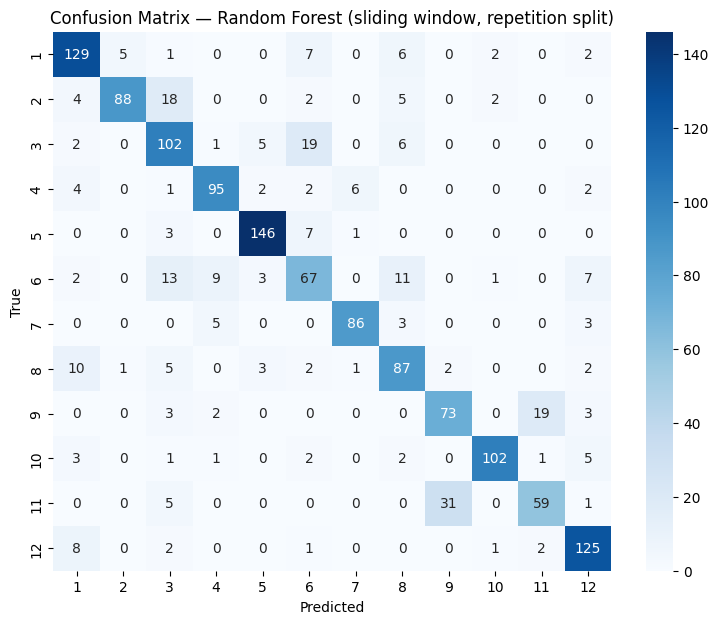

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

test_reps = [2, 5, 7, 10]
train_mask = ~np.isin(rep, test_reps)
test_mask = np.isin(rep, test_reps)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("Train windows:", X_train.shape[0])
print("Test windows:", X_test.shape[0])

# Scale using train statistics only (avoid leaking test distribution into scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Random Forest ---
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# --- KNN ---
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print("=== KNN ===")
print(classification_report(y_test, y_pred_knn, zero_division=0))

# --- Confusion matrix (Random Forest) ---
plt.figure(figsize=(9, 7))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=range(1, 13), yticklabels=range(1, 13))
plt.title("Confusion Matrix — Random Forest (sliding window, repetition split)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


## 7. Gesture 9 vs. 11 Confusion — Why It Happens

The confusion matrix above consistently shows gestures **9 (thumb adduction)** and
**11 (thumb flexion)** as the most confused pair. Both are thumb-only movements driven
by overlapping intrinsic/extrinsic thumb muscles, so some surface-EMG overlap is
anatomically expected rather than a modeling failure.


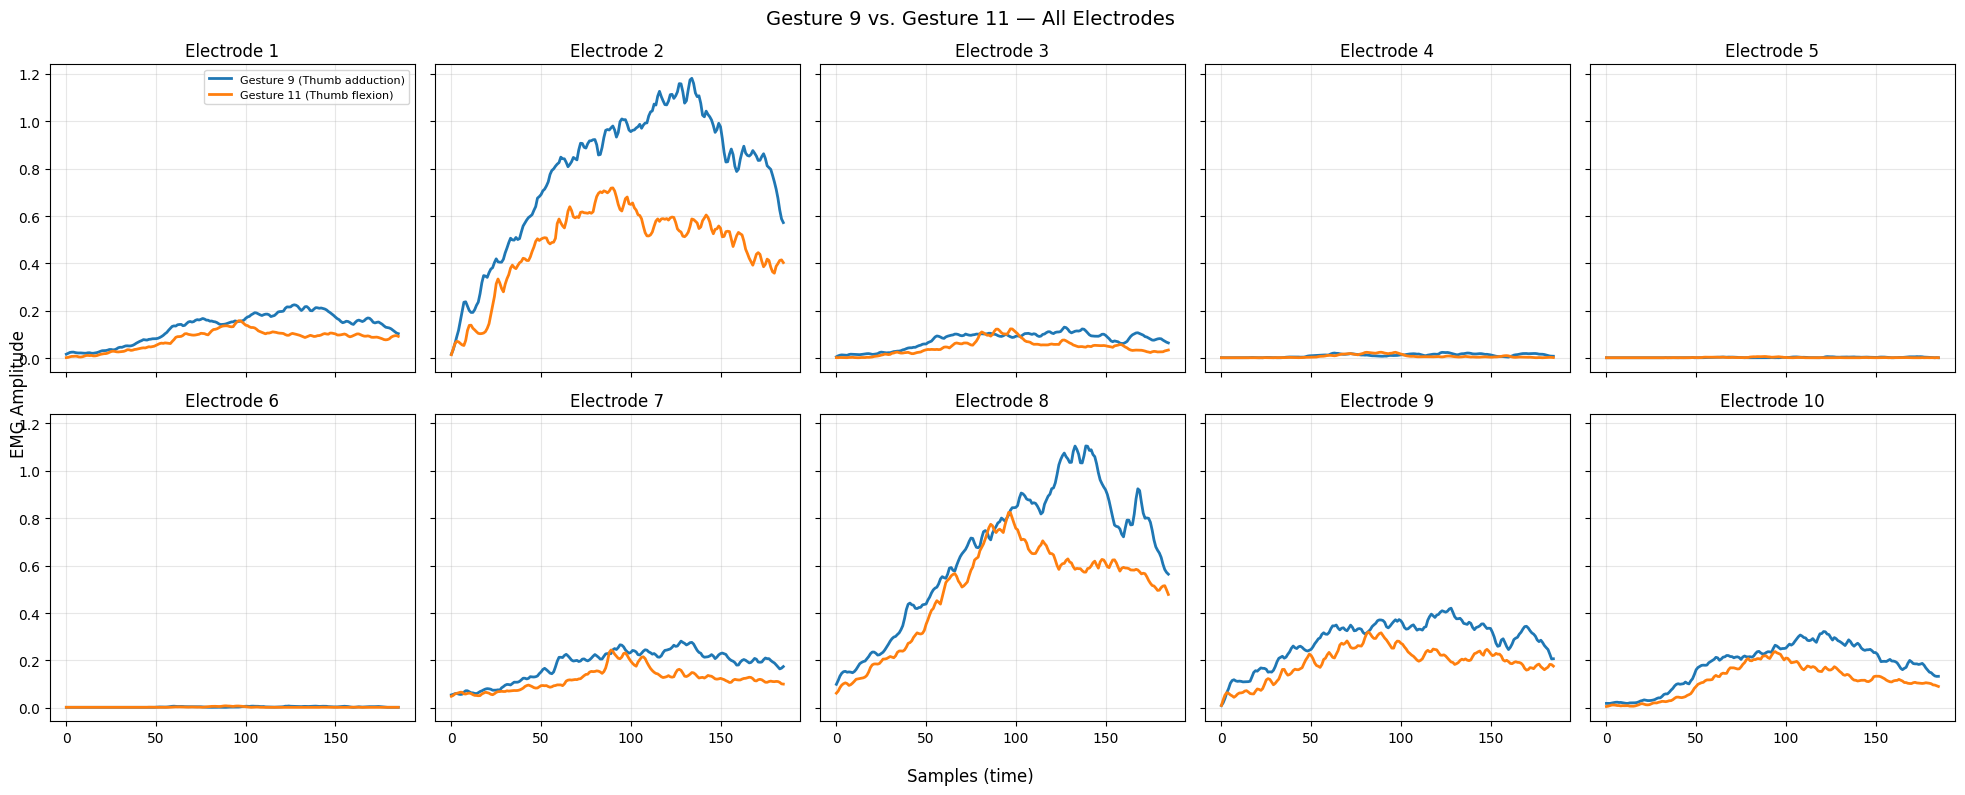

In [21]:
def mean_waveform_pair(g1, g2):
    w1 = get_repetition_windows(g1)
    w2 = get_repetition_windows(g2)
    segs1 = [emg[s:e, :] for s, e in w1]
    segs2 = [emg[s:e, :] for s, e in w2]
    min_len = min(min(s.shape[0] for s in segs1), min(s.shape[0] for s in segs2))
    segs1 = [s[:min_len, :] for s in segs1]
    segs2 = [s[:min_len, :] for s in segs2]
    return np.mean(segs1, axis=0), np.mean(segs2, axis=0)

mean_g9, mean_g11 = mean_waveform_pair(9, 11)

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharex=True, sharey=True)
axes = axes.flatten()
for electrode in range(10):
    ax = axes[electrode]
    ax.plot(mean_g9[:, electrode], label="Gesture 9 (Thumb adduction)", linewidth=2)
    ax.plot(mean_g11[:, electrode], label="Gesture 11 (Thumb flexion)", linewidth=2)
    ax.set_title(f"Electrode {electrode + 1}")
    ax.grid(alpha=0.3)
axes[0].legend(fontsize=8)
fig.supxlabel("Samples (time)")
fig.supylabel("EMG Amplitude")
fig.suptitle("Gesture 9 vs. Gesture 11 — All Electrodes", fontsize=14)
plt.tight_layout()
plt.show()


**Analysis:** across most electrodes the mean waveform shape is highly similar between
the two gestures, differing mainly in amplitude rather than pattern. **Electrode 8**
shows the clearest separation (sharper difference in peak timing/shape), making it the
most informative electrode for distinguishing this specific pair. Electrodes 4–6 show
almost no signal for either gesture, consistent with their placement being farther from
thumb-controlling muscles.

**Takeaway:** this confusion is a partly genuine sensor-placement limitation, not purely
a modeling bug — a fair limitation to note in the final write-up rather than something
to "fix" by tuning hyperparameters.

**Feature importance**, aggregated across the 5 statistics per electrode, cross-checks this: electrodes closer to the more expressive muscles should score higher.

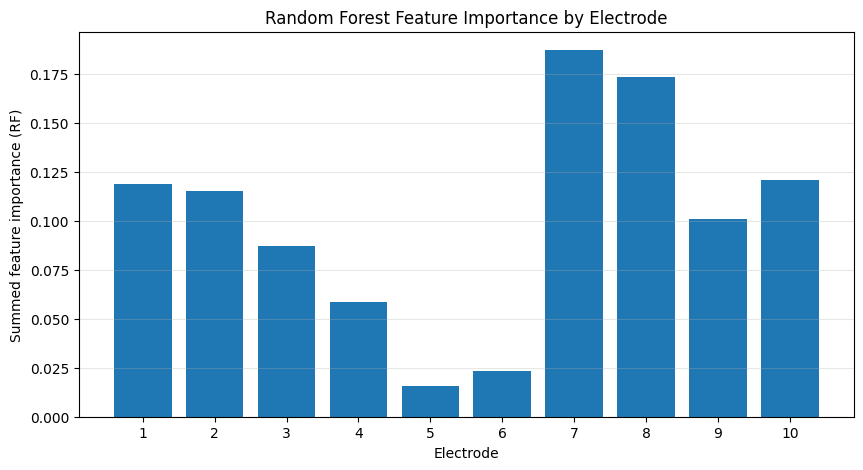

In [22]:
feature_names = [f"E{e+1}_{stat}" for e in range(10) for stat in ["mean", "std", "min", "max", "rms"]]
importances = rf.feature_importances_

# Aggregate the 5 stats per electrode into one importance score per electrode
electrode_importance = importances.reshape(10, 5).sum(axis=1)

plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), electrode_importance)
plt.xticks(range(1, 11))
plt.xlabel("Electrode")
plt.ylabel("Summed feature importance (RF)")
plt.title("Random Forest Feature Importance by Electrode")
plt.grid(axis='y', alpha=0.3)
plt.show()


## 8. Neural Network (MLP)

A small multilayer perceptron on the same 50-dimensional feature vectors, as a point of
comparison against the tree-based models.

**Lesson learned (documented honestly):** an earlier run of this model used
`validation_split` on **class-ordered, unshuffled** data. Since Keras's `validation_split`
just takes the *last* N% of the array — not a random sample — entire gesture classes
were silently excluded from validation. The fix is a joint shuffle of `X_train`/`y_train`
right before fitting, shown below.

In [23]:
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.utils import shuffle

# Keras' sparse_categorical_crossentropy expects 0-indexed labels
y_train_nn = y_train - 1
y_test_nn = y_test - 1

model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


2026-09-13 06:45:55.733244: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 12)             │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,740 (22.42 KB)

 Trainable params: 5,740 (22.42 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Shuffle jointly before fitting -- critical, see note above
X_train_shuf, y_train_shuf = shuffle(X_train_scaled, y_train_nn, random_state=42)

history = model.fit(
    X_train_shuf, y_train_shuf,
    validation_split=0.15,
    epochs=50,
    batch_size=32,
    verbose=1,
)


Epoch 1/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.2623 - loss: 2.2083 - val_accuracy: 0.4689 - val_loss: 1.8435
Epoch 2/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4962 - loss: 1.6317 - val_accuracy: 0.5404 - val_loss: 1.4072
Epoch 3/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5911 - loss: 1.2848 - val_accuracy: 0.6646 - val_loss: 1.1307
Epoch 4/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6498 - loss: 1.0629 - val_accuracy: 0.6522 - val_loss: 0.9792
Epoch 5/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6839 - loss: 0.9358 - val_accuracy: 0.7236 - val_loss: 0.8741
Epoch 6/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7014 - loss: 0.8529 - val_accuracy: 0.7640 - val_loss: 0.8244
Epoch 7/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7201 - loss: 0.8013 - val_accuracy: 0.7640 - val_loss: 0.7440
Epoch 8/50
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7437 - loss: 0.7537 - val_accuracy: 0.8075 - val_loss:

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Neural Network (MLP) ===
              precision    recall  f1-score   support

           1       0.80      0.85      0.82       152
           2       0.80      0.76      0.78       119
           3       0.73      0.90      0.80       135
           4       0.90      0.92      0.91       112
           5       0.93      0.88      0.90       157
           6       0.79      0.58      0.67       113
           7       0.89      0.96      0.92        97
           8       0.82      0.68      0.74       113
           9       0.82      0.51      0.63       100
          10       0.70      0.94      0.80       117
          11       0.61      0.86      0.72        96
          12       0.89      0.69      0.78       139

    accuracy                           0.80      1450
   macro avg       0.81      0.79      0.79      1450
weighted avg       0.81      0.80      0.79      1450



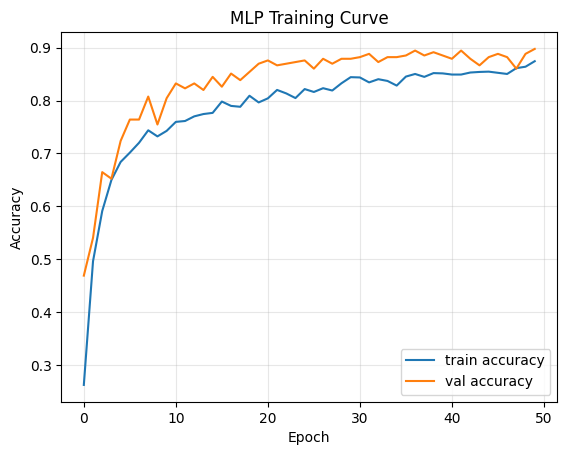

In [25]:
y_pred_nn = model.predict(X_test_scaled).argmax(axis=1) + 1  # back to 1-12 labels

print("=== Neural Network (MLP) ===")
print(classification_report(y_test, y_pred_nn, zero_division=0))

plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP Training Curve')
plt.grid(alpha=0.3)
plt.show()


## 9. MLP + EarlyStopping

**Framing this honestly:** EarlyStopping is added here for **training reliability and
reproducibility**, not as an accuracy booster. In testing, it matched (rather than
beat) a well-chosen fixed epoch count. What it *does* provide: no need to manually guess
the right number of epochs, and automatic protection against overfitting if the
model/data change later (e.g. after adding a CNN or more subjects).

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

# Fresh model -- trained from scratch for a fair comparison against the MLP above
model_es = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model_es.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

history_es = model_es.fit(
    X_train_shuf, y_train_shuf,
    validation_split=0.15,
    epochs=100,          # raised -- EarlyStopping will cut it short
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)


Epoch 1/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2333 - loss: 2.2838 - val_accuracy: 0.4534 - val_loss: 1.9446
Epoch 2/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4468 - loss: 1.7727 - val_accuracy: 0.5559 - val_loss: 1.5714
Epoch 3/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5406 - loss: 1.3960 - val_accuracy: 0.5932 - val_loss: 1.2472
Epoch 4/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6065 - loss: 1.1385 - val_accuracy: 0.7081 - val_loss: 1.0243
Epoch 5/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6630 - loss: 0.9962 - val_accuracy: 0.6832 - val_loss: 0.9218
Epoch 6/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6877 - loss: 0.8911 - val_accuracy: 0.7298 - val_loss: 0.8391
Epoch 7/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7173 - loss: 0.8235 - val_accuracy: 0.7609 - val_loss: 0.7968
Epoch 8/100
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7289 - loss: 0.7818 - val_accuracy: 0.7671 - v

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Neural Network (MLP + EarlyStopping) ===
              precision    recall  f1-score   support

           1       0.80      0.88      0.83       152
           2       0.89      0.77      0.83       119
           3       0.76      0.88      0.82       135
           4       0.89      0.94      0.91       112
           5       0.92      0.87      0.90       157
           6       0.79      0.60      0.68       113
           7       0.92      0.98      0.95        97
           8       0.75      0.69      0.72       113
           9       0.68      0.49      0.57       100
          10       0.78      0.91      0.84       117
          11       0.56      0.74      0.64        96
          12       0.93      0.84      0.88       139

    accuracy                           0.81      1450
   macro avg       0.81      0.80      0.80      1450
weighted avg       0.81      0.81      0.81      1450



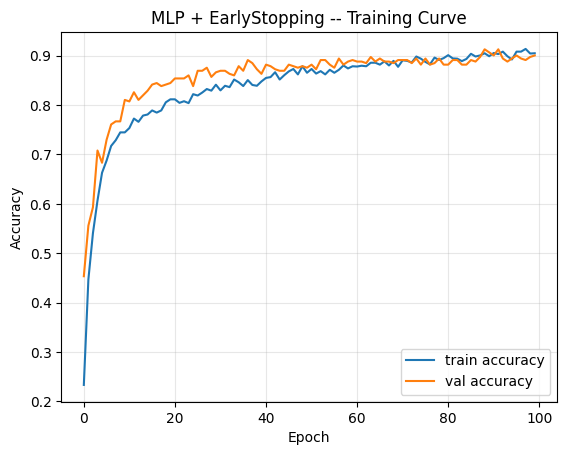

In [27]:
y_pred_es = model_es.predict(X_test_scaled).argmax(axis=1) + 1

print("=== Neural Network (MLP + EarlyStopping) ===")
print(classification_report(y_test, y_pred_es, zero_division=0))

plt.plot(history_es.history['accuracy'], label='train accuracy')
plt.plot(history_es.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP + EarlyStopping -- Training Curve')
plt.grid(alpha=0.3)
plt.show()


## 10. Results Summary & Discussion

| Model | Test Accuracy | Notes |
|---|---|---|
| Random Forest | ~80% | Best classical baseline; robust to feature scale |
| KNN (k=5) | ~76% | Simple, sensitive to feature scaling |
| MLP | ~80–82% | Best overall; needed the shuffle fix to validate correctly |
| MLP + EarlyStopping | ~81% | Matches manually-tuned MLP; adds training robustness, not accuracy |

**Known limitation:** gestures 9 (thumb adduction) and 11 (thumb flexion) are
consistently the most confused pair. Section 7 shows this is a genuine sensor-placement
limitation (overlapping thumb muscle activity), not purely a modeling shortfall —
electrode 8 provides the most separation for this pair, while electrodes 4–6 carry
almost no discriminative signal for the thumb overall.



In [30]:
X_raw, y, rep = [], [], []

for g in range(1, 13):
    for start, end in get_repetition_windows(g):
        rep_number = repetition[start]
        window_start = start
        while window_start + window_size <= end:
            window = emg[window_start: window_start + window_size, :]  # (20, 10)
            X_raw.append(window)
            y.append(g)
            rep.append(rep_number)
            window_start += step_size

X, y, rep = np.array(X_raw), np.array(y), np.array(rep)
print(X.shape)
print(X[0, :, 2])

(3594, 20, 10)
[0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024
 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0024 0.0049]


In [31]:
model_cnn = keras.Sequential([
    layers.Input(shape=(20,10)),
    layers.Conv1D(16, kernel_size = 3, activation='relu'),
    layers.MaxPooling1D(pool_size = 2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(12, activation='softmax'),
])
model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 18, 16)         │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 9, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 144)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         9,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,556 (41.23 KB)

 Trainable params: 10,556 (41.23 KB)

 Non-trainable params: 0 (0.00 B)